In [24]:
!pip install pennylane

In [25]:
!pip install networkx

In [26]:
import pennylane as qp

In [27]:
H=qp.Hamiltonian([1,1,0.5],[qp.PauliX(0),qp.PauliZ(1),qp.PauliX(0)@qp.PauliX(1)])

In [28]:
dev=qp.device("default.qubit",wires=2)
t=1
n=2
@qp.qnode(dev)
def circuit():
  qp.ApproxTimeEvolution(H,t,n)
  return [qp.expval(qp.PauliZ(i) for i in range(2))]
print(qp.draw(circuit,level="device"))

<function circuit at 0x7c6648573a60>


In [29]:
def circ(theta):
  qp.RX(theta,wires=0)
  qp.Hadamard(wires=1)
  qp.CNOT(wires=[0,1])

@qp.qnode(dev)
def circuit(param):
  circ(param)
  return [qp.expval(qp.PauliZ(i)) for i in range(2)]

In [30]:
@qp.qnode(dev)
def circuit(params,**kwargs):
  qp.layer(circ,3,params)
  return [qp.expval(qp.PauliZ(i)) for i in range(2)]

In [31]:
from pennylane import qaoa
from pennylane import numpy as np
from matplotlib import pyplot as plt
import networkx as nx

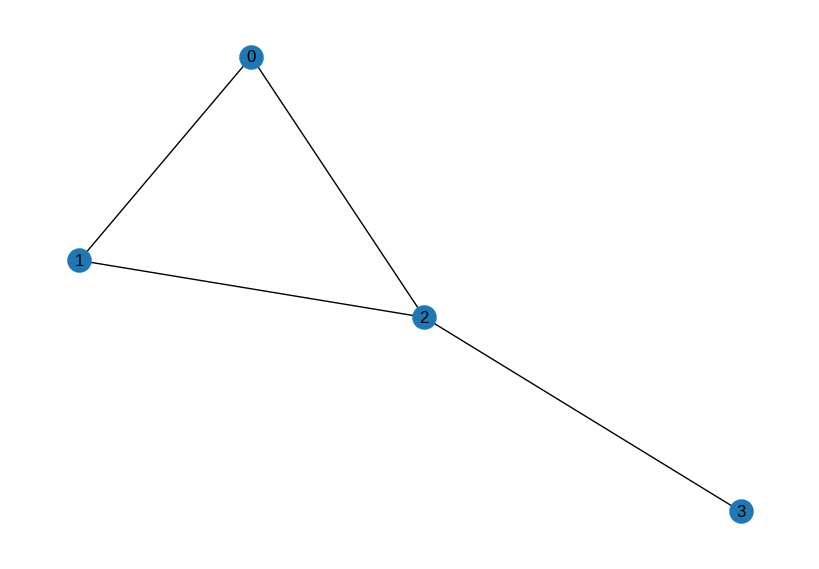

In [32]:
edges=[(0,1),(1,2),(2,0),(2,3)]
graph=nx.Graph(edges)
positions=nx.spring_layout(graph,seed=1)

nx.draw(graph,with_labels=True,pos=positions)
plt.show()


In [33]:
cost_h,mixer_h=qaoa.min_vertex_cover(graph,constrained=False)
print(cost_h)
print(mixer_h)

0.75 * (Z(0) @ Z(1)) + 0.75 * Z(0) + 0.75 * Z(1) + 0.75 * (Z(0) @ Z(2)) + 0.75 * Z(0) + 0.75 * Z(2) + 0.75 * (Z(1) @ Z(2)) + 0.75 * Z(1) + 0.75 * Z(2) + 0.75 * (Z(2) @ Z(3)) + 0.75 * Z(2) + 0.75 * Z(3) + -1.0 * Z(0) + -1.0 * Z(1) + -1.0 * Z(2) + -1.0 * Z(3)
1 * X(0) + 1 * X(1) + 1 * X(2) + 1 * X(3)


In [34]:
def qaoa_layer(gamma,alpha):
  qaoa.cost_layer(gamma,cost_h)
  qaoa.mixer_layer(alpha,mixer_h)


In [35]:
wires=range(4)
depth=2
def circuit(params, **kwargs):
  for w in wires:
    qp.Hadamard(wires=w)
  qp.layer(qaoa_layer,depth,params[0],params[1])


In [36]:
dev=qp.device("default.qubit",wires=wires)

In [37]:
@qp.qnode(dev)
def cost_function(params):
  circuit(params)
  return qp.expval(cost_h)

In [38]:
optimizer=qp.GradientDescentOptimizer()
steps=70
params=np.array([[0.5,0.5],[0.5,0.5]],requires_grad=True)

In [39]:
for i in range(steps):
  params=optimizer.step(cost_function,params)


In [40]:
print(params)

[[0.59806352 0.94198485]
 [0.52797281 0.85552845]]


In [41]:
@qp.qnode(dev)
def prob_circuit(gamma,alpha):
  circuit([gamma,alpha])
  return qp.probs(wires=wires)
probs=prob_circuit(params[0],params[1])

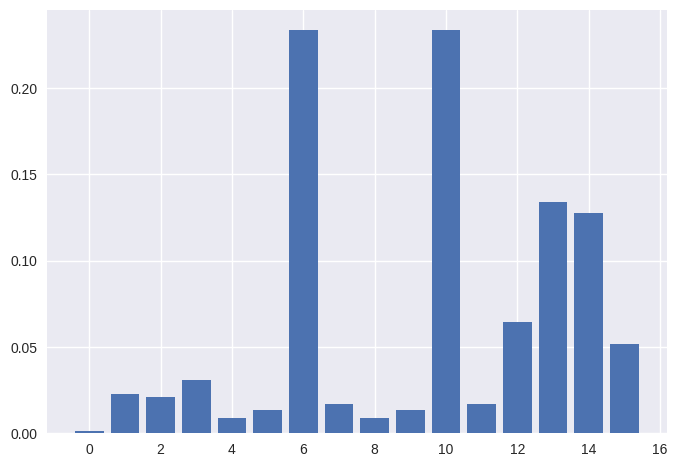

In [42]:
plt.style.use("seaborn-v0_8")
plt.bar(range(2**len(wires)),probs)
plt.show()

In [44]:
reward_h=qaoa.edge_driver(nx.Graph([(0,2)]),["11"])
new_cost_h=cost_h+2*reward_h



In [45]:
def qaoa_layer(gamma,alpha):
  qaoa.cost_layer(gamma,new_cost_h)
  qaoa.mixer_layer(alpha,mixer_h)
def circuit(params,**kwargs):
  for w in wires:
    qp.Hadamard(wires=w)
  qp.layer(qaoa_layer,depth,params[0],params[1])
@qp.qnode(dev)
def cost_function(params):
  circuit(params)
  return qp.expval(new_cost_h)
params=np.array([[0.5,0.5],[0.5,0.5]],requires_grad=True)
for i in range(steps):
  params=optimizer.step(cost_function,params)
print(params)

[[0.45959941 0.96095271]
 [0.27029962 0.78042396]]


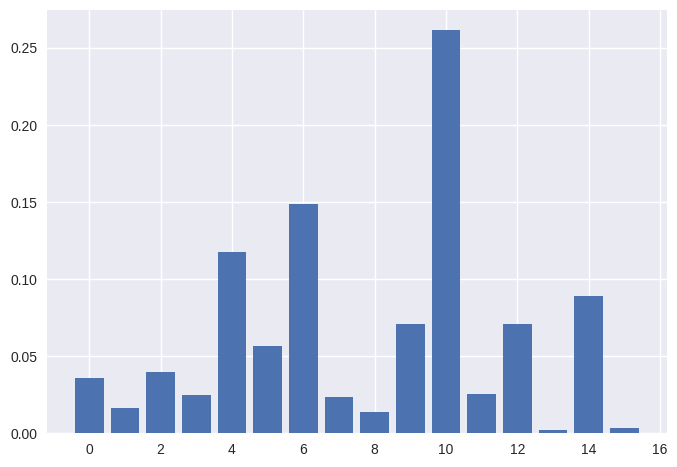

In [46]:
@qp.qnode(dev)
def prob_circuit(gamma,alpha):
  circuit([gamma,alpha])
  return qp.probs(wires=wires)
probs=prob_circuit(params[0],params[1])
plt.style.use("seaborn-v0_8")
plt.bar(range(2**len(wires)),probs)
plt.show()